### 라이브러리 및 MongoDB 연결

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pymongo import MongoClient
from dotenv import load_dotenv
import os
import warnings
warnings.filterwarnings("ignore")

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

load_dotenv("../../collect_data/hyerim/.env")
client = MongoClient(os.getenv("MONGO_URI"))
db = client["data_hyerim"]
print("MongoDB 연결 완료")

MongoDB 연결 완료


### 데이터 불러오기

In [4]:
cursor = db["stock_ohlcv_kospi200"].find({}, {"_id": 0})
df = pd.DataFrame(list(cursor))

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["stock_code", "date"]).reset_index(drop=True)

print(f"shape: {df.shape}")
print(f"종목 수: {df['stock_code'].nunique()}")
print(f"기간: {df['date'].min()} ~ {df['date'].max()}")
df.head()

shape: (135356, 12)
종목 수: 115
기간: 2021-06-18 00:00:00 ~ 2026-06-16 00:00:00


,stock_code,date,close,collected_at,high,interval,low,open,source,trade_value,volume,stock_name
0,000100,2021-06-18,56077,2026-06-17 13:19:34.836,56077,1day,55200,55463,kis,18207998900,326757,유한양행
1,000100,2021-06-21,55376,2026-06-17 13:19:34.835,55551,1day,54938,55463,kis,16939607700,307332,유한양행
2,000100,2021-06-22,55463,2026-06-17 13:19:34.835,55726,1day,55200,55288,kis,8127657700,146688,유한양행
3,000100,2021-06-23,55025,2026-06-17 13:19:34.835,55639,1day,54938,55551,kis,15206258700,275885,유한양행
4,000100,2021-06-24,55288,2026-06-17 13:19:34.835,55463,1day,55025,55200,kis,9393488600,169991,유한양행


### 기본 정보 확인

In [5]:
print(df.dtypes)
print("\n결측치:")
print(df.isnull().sum())
print("\n기본 통계:")
df[["open","high","low","close","volume"]].describe()

stock_code              object
date            datetime64[ns]
close                    int64
collected_at    datetime64[ns]
high                     int64
interval                object
low                      int64
open                     int64
source                  object
trade_value              int64
volume                   int64
stock_name              object
dtype: object

결측치:
stock_code      0
date            0
close           0
collected_at    0
high            0
interval        0
low             0
open            0
source          0
trade_value     0
volume          0
stock_name      0
dtype: int64

기본 통계:


,open,high,low,close,volume
count,1.353560e+05,1.353560e+05,1.353560e+05,1.353560e+05,1.353560e+05
mean,1.293261e+05,1.318131e+05,1.268806e+05,1.292442e+05,1.082461e+06
std,2.006858e+05,2.047405e+05,1.966005e+05,2.004815e+05,3.162790e+06
min,1.930000e+03,1.965000e+03,1.895000e+03,1.895000e+03,0.000000e+00
25%,2.829200e+04,2.885000e+04,2.771200e+04,2.825000e+04,1.495455e+05
50%,6.750000e+04,6.860000e+04,6.650000e+04,6.747400e+04,3.606785e+05
75%,1.447000e+05,1.478000e+05,1.420000e+05,1.448000e+05,9.074998e+05
max,2.381000e+06,2.489000e+06,2.296000e+06,2.382000e+06,1.634642e+08


### 종목 별 데이터 수 확인

In [6]:
stock_counts = df.groupby(["stock_code","stock_name"]).size().reset_index(name="count")
print(stock_counts.sort_values("count"))

    stock_code stock_name  count
72      064400     LG씨엔에스    332
90      111770       영원무역    453
68      051910       LG화학    500
105     278470       에이피알    558
93      138930    BNK금융지주   1029
..         ...        ...    ...
109     326030     SK바이오팜   1221
96      180640        한진칼   1221
111     336260      두산퓨얼셀   1221
112     352820        하이브   1221
113     353200       대덕전자   1221

[115 rows x 3 columns]


### 삼성전자 종가/거래량 시각화

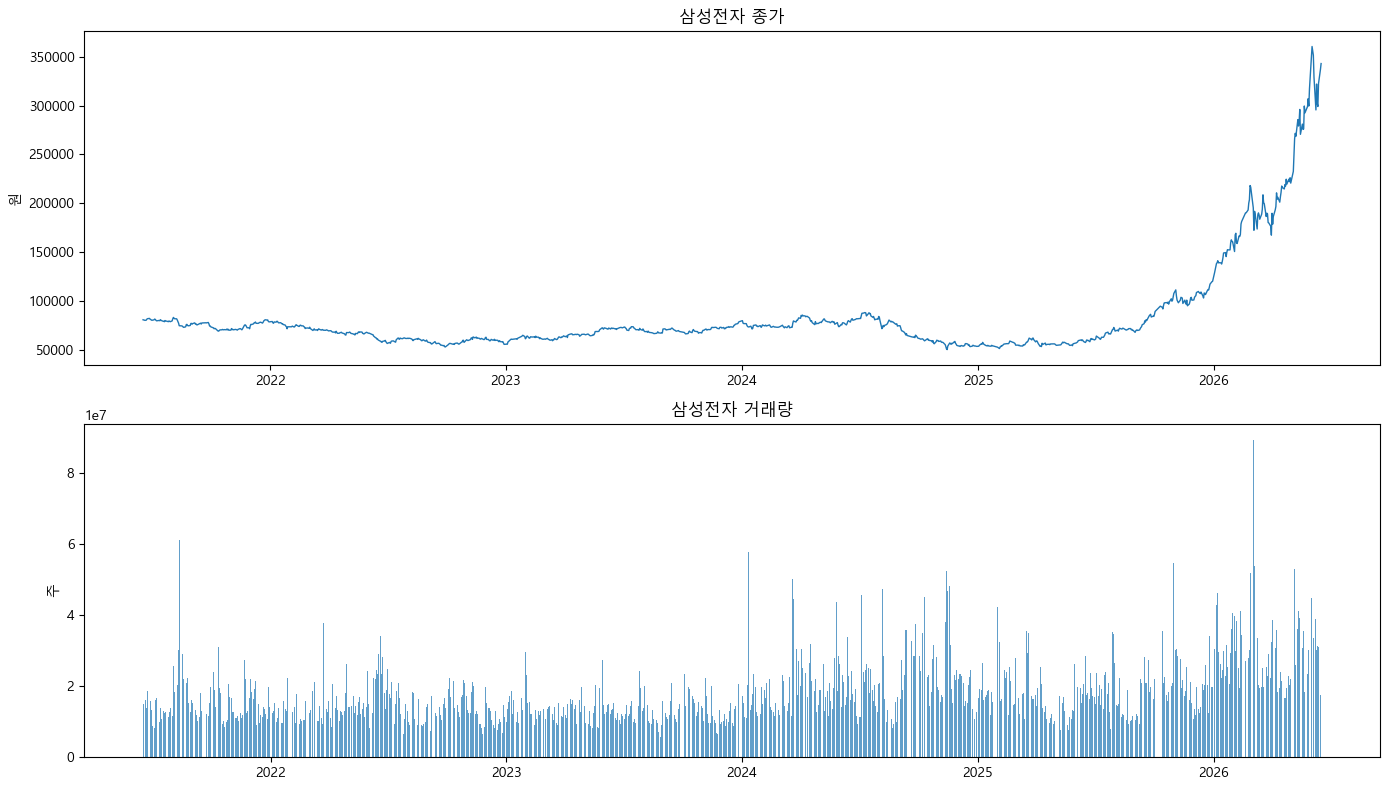

In [7]:
df_ss = df[df["stock_code"] == "005930"].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df_ss["date"], df_ss["close"], linewidth=1)
axes[0].set_title("삼성전자 종가")
axes[0].set_ylabel("원")

axes[1].bar(df_ss["date"], df_ss["volume"], width=1, alpha=0.7)
axes[1].set_title("삼성전자 거래량")
axes[1].set_ylabel("주")

plt.tight_layout()
plt.show()

### 이동평균선 계산 및 시각화

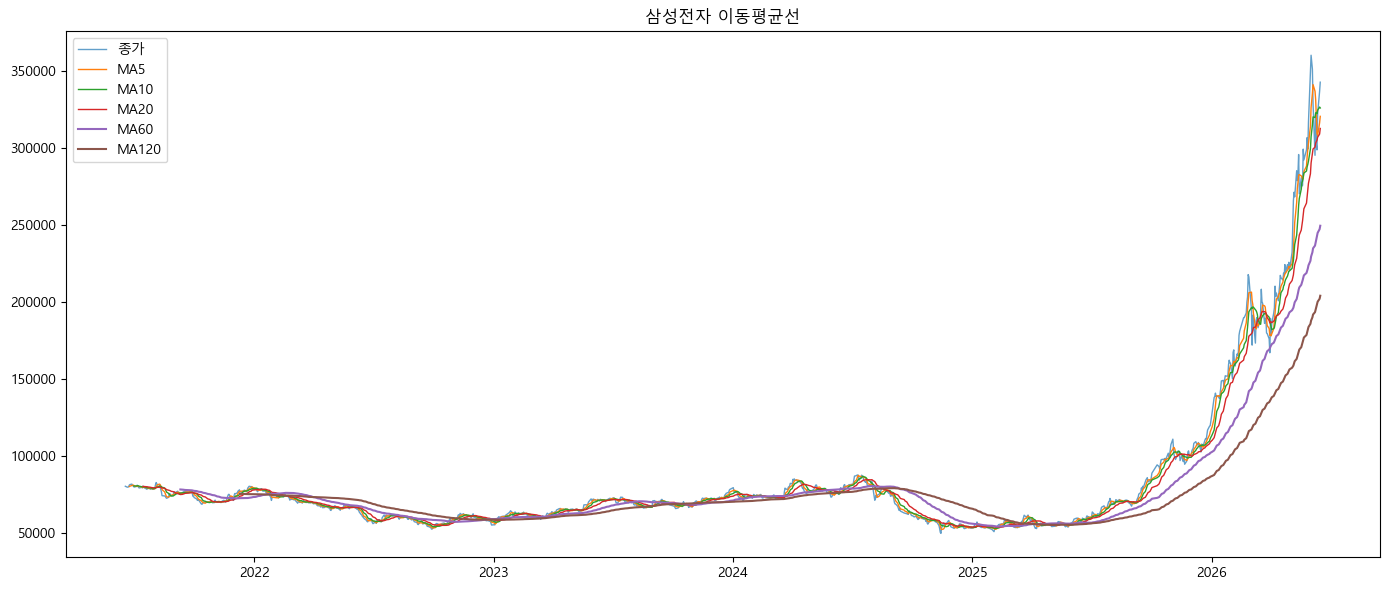

In [8]:
df_ss = df_ss.sort_values("date").copy()

df_ss["ma5"]   = df_ss["close"].rolling(5).mean()
df_ss["ma10"]  = df_ss["close"].rolling(10).mean()
df_ss["ma20"]  = df_ss["close"].rolling(20).mean()
df_ss["ma60"]  = df_ss["close"].rolling(60).mean()
df_ss["ma120"] = df_ss["close"].rolling(120).mean()

plt.figure(figsize=(14, 6))
plt.plot(df_ss["date"], df_ss["close"],  label="종가",   linewidth=1, alpha=0.7)
plt.plot(df_ss["date"], df_ss["ma5"],    label="MA5",    linewidth=1)
plt.plot(df_ss["date"], df_ss["ma10"],   label="MA10",   linewidth=1)
plt.plot(df_ss["date"], df_ss["ma20"],   label="MA20",   linewidth=1)
plt.plot(df_ss["date"], df_ss["ma60"],   label="MA60",   linewidth=1.5)
plt.plot(df_ss["date"], df_ss["ma120"],  label="MA120",  linewidth=1.5)
plt.legend()
plt.title("삼성전자 이동평균선")
plt.tight_layout()
plt.show()

### 볼린저밴드 시각화

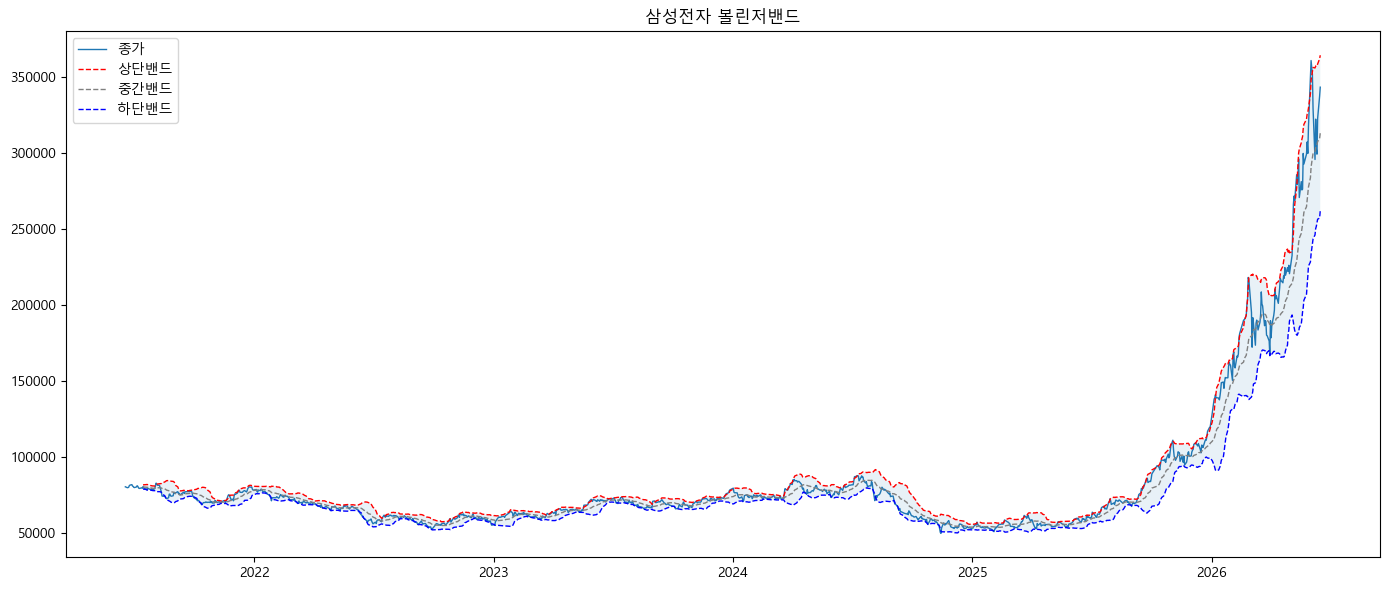

In [9]:
df_ss["bb_mid"]   = df_ss["close"].rolling(20).mean()
df_ss["bb_std"]   = df_ss["close"].rolling(20).std()
df_ss["bb_upper"] = df_ss["bb_mid"] + 2 * df_ss["bb_std"]
df_ss["bb_lower"] = df_ss["bb_mid"] - 2 * df_ss["bb_std"]

plt.figure(figsize=(14, 6))
plt.plot(df_ss["date"], df_ss["close"],    label="종가",     linewidth=1)
plt.plot(df_ss["date"], df_ss["bb_upper"], label="상단밴드", linewidth=1, linestyle="--", color="red")
plt.plot(df_ss["date"], df_ss["bb_mid"],   label="중간밴드", linewidth=1, linestyle="--", color="gray")
plt.plot(df_ss["date"], df_ss["bb_lower"], label="하단밴드", linewidth=1, linestyle="--", color="blue")
plt.fill_between(df_ss["date"], df_ss["bb_upper"], df_ss["bb_lower"], alpha=0.1)
plt.legend()
plt.title("삼성전자 볼린저밴드")
plt.tight_layout()
plt.show()

### 거래량 급등 비율 분포

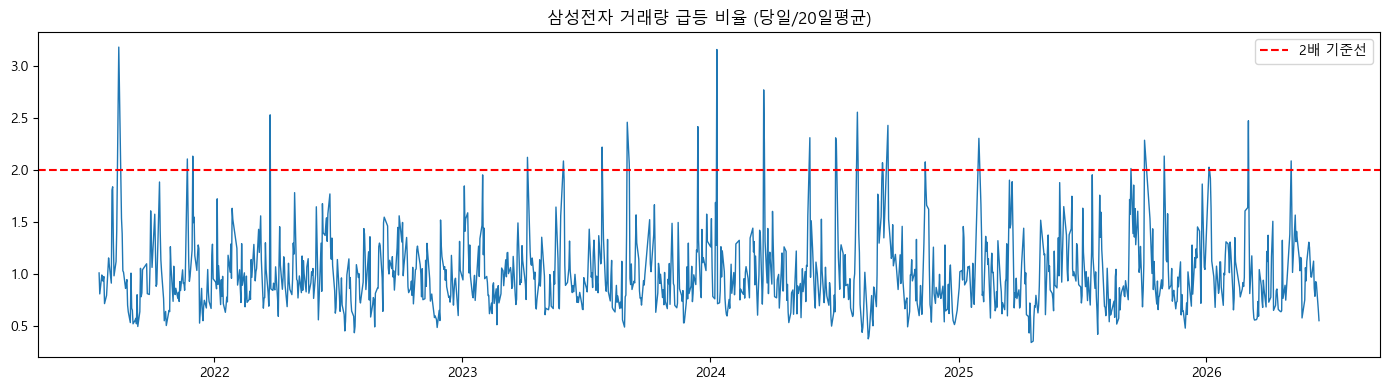

In [10]:
df_ss["vol_ratio"] = df_ss["volume"] / df_ss["volume"].rolling(20).mean()

plt.figure(figsize=(14, 4))
plt.plot(df_ss["date"], df_ss["vol_ratio"], linewidth=1)
plt.axhline(y=2, color="red", linestyle="--", label="2배 기준선")
plt.legend()
plt.title("삼성전자 거래량 급등 비율 (당일/20일평균)")
plt.tight_layout()
plt.show()

### 시장 지표 불러오기

In [11]:
cursor = db["market_indicators"].find({}, {"_id": 0})
df_market = pd.DataFrame(list(cursor))
df_market["date"] = pd.to_datetime(df_market["date"])
df_market = df_market.sort_values(["indicator", "date"]).reset_index(drop=True)

print(f"shape: {df_market.shape}")
print(f"지표 목록: {df_market['indicator'].unique()}")
df_market.head()

shape: (25067, 8)
지표 목록: ['dow' 'gold' 'kosdaq' 'kospi' 'nasdaq' 'sp500' 'usd_index' 'usd_krw'
 'vix' 'wti']


,indicator,date,close,collected_at,high,low,open,volume
0,dow,2016-06-20,17804.869141,2026-06-17 10:42:23.745,17946.359375,17736.869141,17736.869141,99380000.0
1,dow,2016-06-21,17829.730469,2026-06-17 10:42:23.745,17877.839844,17799.800781,17827.330078,85130000.0
2,dow,2016-06-22,17780.830078,2026-06-17 10:42:23.745,17920.160156,17770.359375,17832.669922,89440000.0
3,dow,2016-06-23,18011.070312,2026-06-17 10:42:23.745,18011.070312,17844.109375,17844.109375,98070000.0
4,dow,2016-06-24,17400.750000,2026-06-17 10:42:23.745,17946.630859,17356.339844,17946.630859,239000000.0


### 시장 지표 시각화

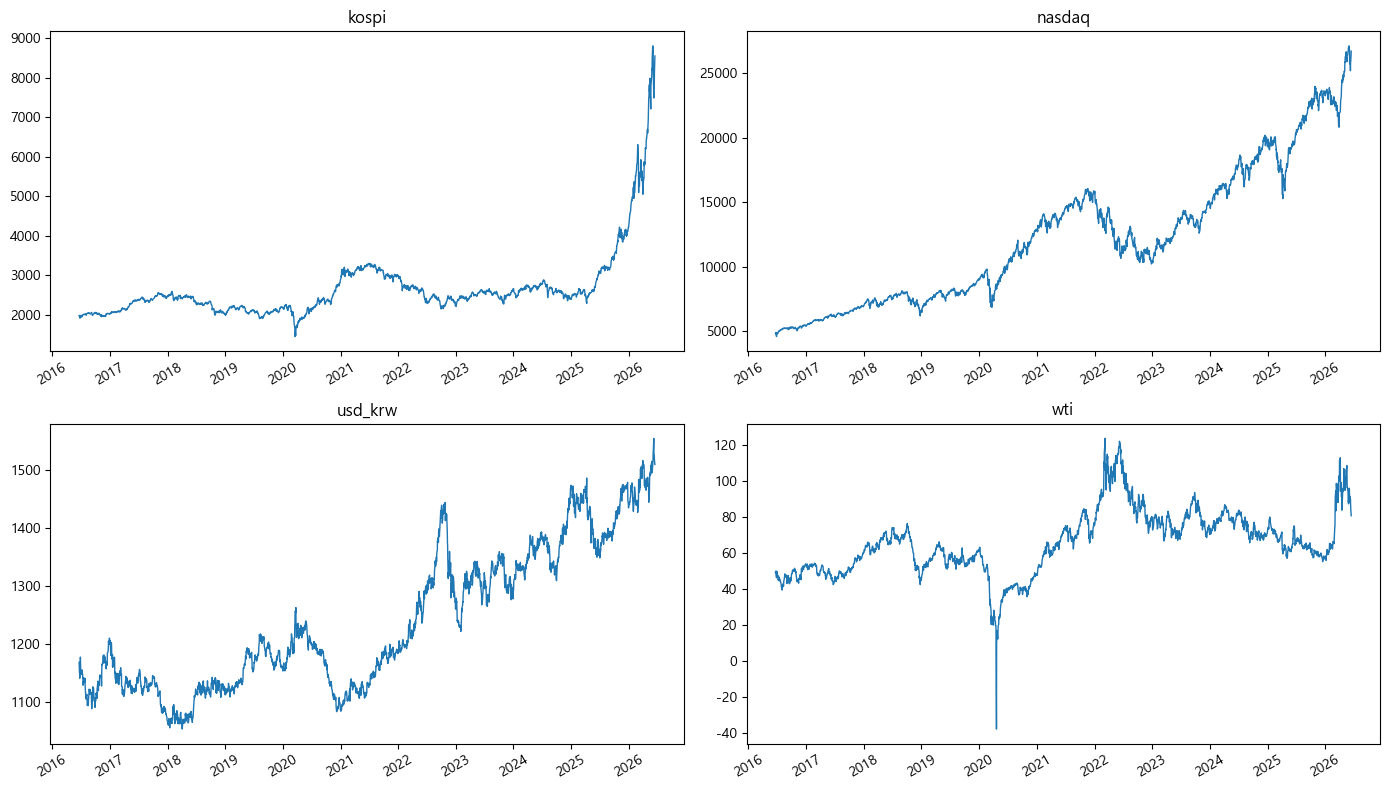

In [13]:
indicators = ["kospi", "nasdaq", "usd_krw", "wti"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for ax, name in zip(axes.flatten(), indicators):
    data = df_market[df_market["indicator"] == name]
    ax.plot(data["date"], data["close"], linewidth=1)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()